In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import pyemma
from pyemma.util.contexts import settings
import os

In [ ]:
contact_files = [
    "feature.data"
]

full_file_paths = [os.path.join(file_dir, fname) for fname in contact_files]
for fpath in full_file_paths:
    if not os.path.exists(fpath):
        raise FileNotFoundError(
            f"File not found: {fpath}. Please check that the file path/directory is correct."
        )

print("All file paths are valid. Loading data...")

All file paths are valid. Loading data...


In [4]:
def load_and_clean_contact_data(file_path):
    # Read whitespace-separated .dat file (first row is header)
    df = pd.read_csv(file_path, sep=r"\s+", header=0)

    target_feature_cols = 36

    # Drop the time column (assumes the first column is time)
    if df.shape[1] > target_feature_cols:
        df = df.iloc[:, 1:]

    # Keep only the first 36 residue/feature columns
    if df.shape[1] > target_feature_cols:
        df = df.iloc[:, :target_feature_cols]

    # Convert to numeric array
    contacts = df.to_numpy(dtype=np.float64)

    # Clean invalid values
    contacts = np.nan_to_num(contacts, nan=0.0)
    contacts[contacts < 0] = 0.0

    return contacts

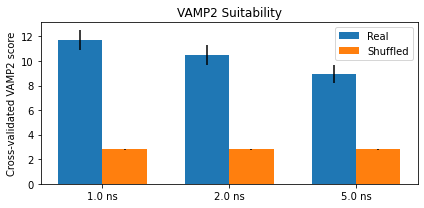

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pyemma

def vamp2_cv_mean_std(data_list, dim, lag, n_splits=10, val_frac=0.5, seed=0):
    """
    Compute a cross-validated VAMP2 score for a given lag and VAMP dimension.

    What this does:
    - Randomly split the *list of trajectories* into a training set and a validation set.
    - Fit a VAMP model on the training trajectories (with the given lag, dim).
    - Evaluate the VAMP2 score on the validation trajectories.
    - Repeat n_splits times and return mean/std of the scores.

    Interpretation:
    - Higher score => this feature set can better capture slow dynamical processes at that lag.
    - Std reflects how sensitive the score is to how you split trajectories (stability).
    """
    rng = np.random.default_rng(seed)
    nval = max(1, int(len(data_list) * val_frac))  # how many trajectories go to validation
    scores = []

    # Avoid noisy progress bar output in notebooks
    with pyemma.util.contexts.settings(show_progress_bars=False):
        for _ in range(n_splits):
            # Choose which trajectories become the validation set in this split
            ival = rng.choice(len(data_list), size=nval, replace=False)
            train = [d for i, d in enumerate(data_list) if i not in ival]
            val   = [d for i, d in enumerate(data_list) if i in ival]

            # Fit VAMP on training data
            vamp = pyemma.coordinates.vamp(train, lag=lag, dim=dim)

            # Score on validation data (cross-validated VAMP2 score)
            scores.append(vamp.score(val))

    scores = np.array(scores, dtype=float)
    return scores.mean(), scores.std()

def time_shuffle(data_list, seed=0):
    """
    Create a negative control ("baseline") by shuffling time order within each trajectory.

    Why we do this:
    - Shuffling destroys temporal correlations (i.e., dynamics),
      but keeps the distribution of feature values.
    - If your features truly encode dynamical/slow-process information,
      the real data should score higher than this shuffled control.
    """
    rng = np.random.default_rng(seed)
    out = []
    for x in data_list:
        idx = np.arange(x.shape[0])
        rng.shuffle(idx)
        out.append(x[idx])
    return out

# ----------------------------
# Ensure the input is a list of trajectories
# ----------------------------
# PyEMMA expects a list: [traj1, traj2, traj3, ...]
# where each traj is an array with shape (n_frames, n_features).
if isinstance(contacts_data_36feat, np.ndarray):
    features = [contacts_data_36feat]
else:
    features = contacts_data_36feat

# ----------------------------
# Define what we are testing
# ----------------------------
# dim: how many slow processes (VAMP components) we keep when scoring
# lags: test several lag times (in frames) to see if results are consistent
# dt_ns: conversion from "frames" to ns for plot labels
dim = 36
lags = [5, 10, 25]   # in frames
dt_ns = 0.2          # ns per frame

# ----------------------------
# Build the shuffled (negative control) dataset
# ----------------------------
# This keeps the same values but breaks time structure.
shuf = time_shuffle(features, seed=0)

# ----------------------------
# For each lag, compute:
# - real CV-VAMP2 score (mean±std)
# - shuffled CV-VAMP2 score (mean±std)
# - a separation metric z = (real - shuffled) / combined_std
# ----------------------------
# The separation z answers: "How many standard deviations is Real above the baseline?"
rows = []
for lag in lags:
    rm, rs = vamp2_cv_mean_std(features, dim=dim, lag=lag, n_splits=10, val_frac=0.5, seed=0)
    sm, ss = vamp2_cv_mean_std(shuf,     dim=dim, lag=lag, n_splits=10, val_frac=0.5, seed=0)

    z = (rm - sm) / max(1e-12, np.sqrt(rs**2 + ss**2))
    rows.append((lag, lag * dt_ns, rm, rs, sm, ss, z))


# ----------------------------
# Plot Real vs Shuffled for each lag and save the figure
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 3))
x = np.arange(len(lags))

real_means = [r[2] for r in rows]
real_stds  = [r[3] for r in rows]
shuf_means = [r[4] for r in rows]
shuf_stds  = [r[5] for r in rows]

w = 0.35
ax.bar(x - w/2, real_means, w, yerr=real_stds, label="Real", color="#1f77b4")
ax.bar(x + w/2, shuf_means, w, yerr=shuf_stds, label="Shuffled", color="#ff7f0e")

ax.set_xticks(x)
ax.set_xticklabels([f"{lag*dt_ns:.1f} ns" for lag in lags])
ax.set_ylabel("Cross-validated VAMP2 score")
ax.set_title(f"VAMP2 Suitability")
ax.legend()

# make sure out_png is defined before saving
out_png = "H3_contacts_36feat_vamp2_suitability.png"

fig.tight_layout()
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


In [8]:
tica = pyemma.coordinates.tica(contacts_data_36feat, lag=5)
tica_output = tica.get_output()
tica_concatenated = np.concatenate(tica_output)

calculate covariances:   0%|          | 0/6 [00:00<?, ?it/s]

getting output of TICA:   0%|          | 0/6 [00:00<?, ?it/s]

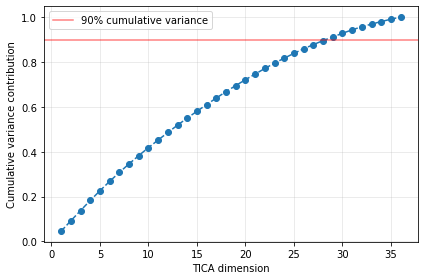

In [9]:
variance_contributions = tica.eigenvalues / tica.eigenvalues.sum()
cumulative_variance = np.cumsum(variance_contributions)

fig, ax = plt.subplots()
ax.plot(range(1, len(cumulative_variance)+1), cumulative_variance, '--o', color='C0')
ax.axhline(y=0.9, color='red', linestyle='-', alpha=0.5, label='90% cumulative variance')
ax.set_xlabel('TICA dimension')
ax.set_ylabel('Cumulative variance contribution')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

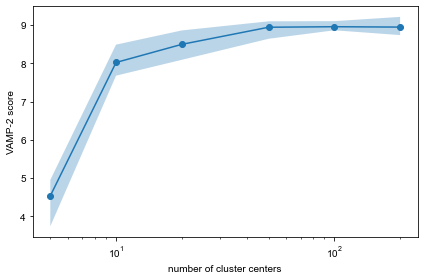

In [25]:
n_clustercenters = [5, 10, 20, 50, 100, 200]

# Purpose: choose a suitable number of cluster centers (k) for discretizing the TICA space.
# We scan different k values and use cross-validated VAMP2 scores to see which discretization
# best captures the slow dynamics (typically picking k where the score starts to plateau).
scores = np.zeros((len(n_clustercenters), 5))
for n, k in enumerate(n_clustercenters):
    for m in range(5):
        with pyemma.util.contexts.settings(show_progress_bars=False):
            _cl = pyemma.coordinates.cluster_kmeans(
                tica_output, k=k, max_iter=50, stride=20)
            _msm = pyemma.msm.estimate_markov_model(_cl.dtrajs, 50)
            scores[n, m] = _msm.score_cv(
                _cl.dtrajs, n=1, score_method='VAMP2', score_k=min(10, k))

fig, ax = plt.subplots()
lower, upper = pyemma.util.statistics.confidence_interval(scores.T.tolist(), conf=0.9)
ax.fill_between(n_clustercenters, lower, upper, alpha=0.3)
ax.plot(n_clustercenters, np.mean(scores, axis=1), '-o')
ax.semilogx()
ax.set_xlabel('number of cluster centers')
ax.set_ylabel('VAMP-2 score')
fig.tight_layout()

In [26]:
cluster = pyemma.coordinates.cluster_kmeans(
    tica_output, k=100, max_iter=100, stride=1, fixed_seed=1)
dtrajs_concatenated = np.concatenate(cluster.dtrajs)

initialize kmeans++ centers:   0%|          | 0/100 [00:00<?, ?it/s]

kmeans iterations:   0%|          | 0/100 [00:00<?, ?it/s]

getting output of KmeansClustering:   0%|          | 0/6 [00:00<?, ?it/s]

estimating MaximumLikelihoodMSM:   0%|          | 0/12 [00:00<?, ?it/s]

Text(0, 0.5, 'implied timescale (ns)')

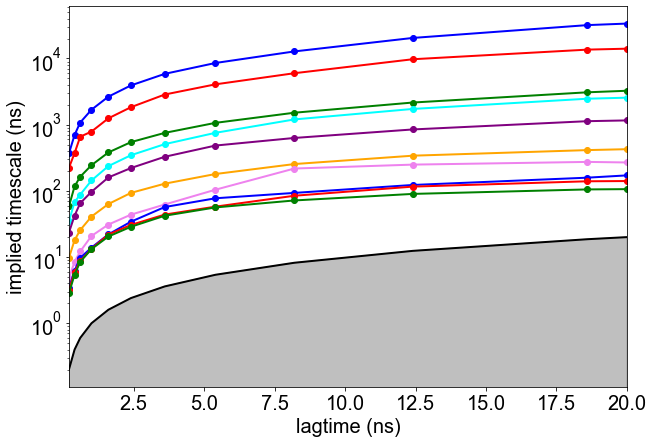

In [28]:
its = pyemma.msm.its(
    cluster.dtrajs, 
    lags=100, 
    nits=10,
    n_jobs=1
)

fig, ax = plt.subplots(figsize=(10, 7))

frame_rate_ns = 0.2

pyemma.plots.plot_implied_timescales(its, units='ns', dt=frame_rate_ns, ax=ax, marker='o', markersize=6, linewidth=2)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=14)
ax.set_xlabel('lagtime (ns)', fontsize=20)
ax.set_ylabel('implied timescale (ns)', fontsize=20)

In [30]:
msm = pyemma.msm.bayesian_markov_model(cluster.dtrajs, lag=50, dt_traj='0.2 ns')
print('fraction of states used = {:.2f}'.format(msm.active_state_fraction))
print('fraction of counts used = {:.2f}'.format(msm.active_count_fraction))

pyemma.msm.estimators.bayesian_msm.BayesianMSM[1343]: Sampling MSMs:   0%|          | 0/100 [00:00<?, ?it/s]

fraction of states used = 1.00
fraction of counts used = 1.00


estimating BayesianMSM:   0%|          | 0/5 [00:00<?, ?it/s]

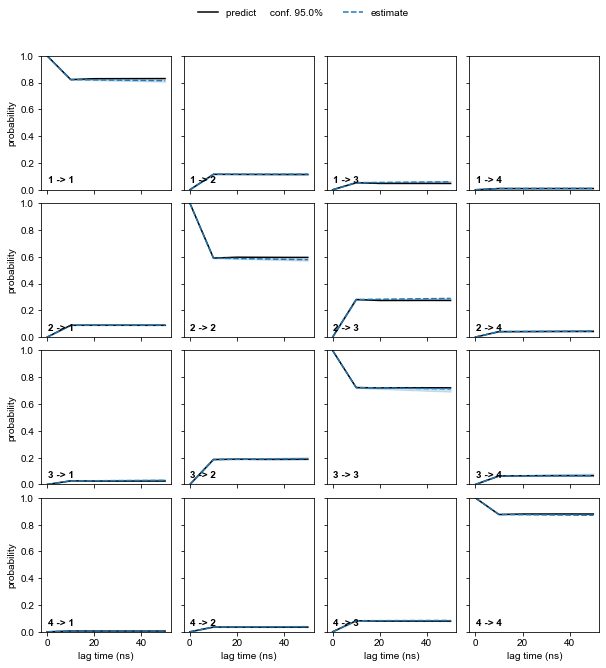

In [31]:
nstates = 4
cktest = msm.cktest(nstates, mlags=6)
pyemma.plots.plot_cktest(cktest, dt=0.2, units='ns')
plt.savefig('H3K36M_CCK_test_4states.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

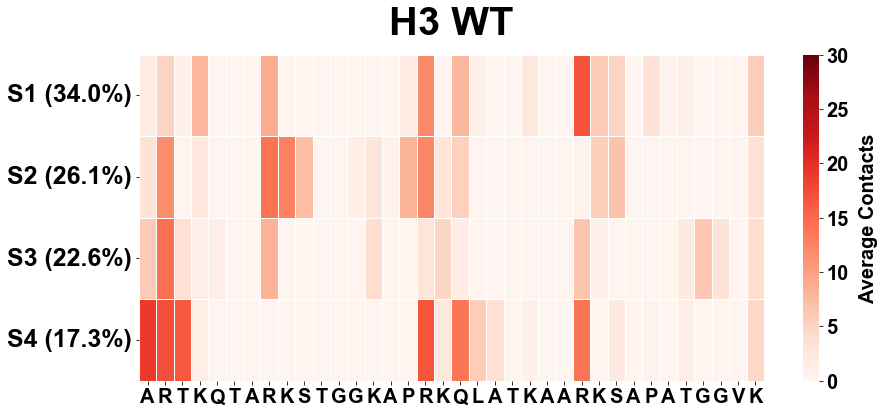

In [32]:
import seaborn as sns
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False

dtrajs_concatenated = np.concatenate(msm.dtrajs_active)
metastable_assignments = msm.metastable_assignments
macro_traj = metastable_assignments[dtrajs_concatenated]

if 'contacts_data_36feat' in locals():
    all_contacts_data = np.concatenate(contacts_data_36feat)
else:
    pass

if 'pi_macro' not in locals():
    pi_macro = msm.metastable_memberships.T @ msm.pi

state_fingerprints = np.zeros((nstates, 36))

for i in range(nstates):
    indices = np.where(macro_traj == i)[0]
    if len(indices) > 0:
        state_fingerprints[i] = np.mean(all_contacts_data[indices], axis=0)

sorted_indices = np.argsort(pi_macro)[::-1]
sorted_fingerprints = state_fingerprints[sorted_indices]

new_yticklabels = [
    f"S{i+1} ({pi_macro[idx]*100:.1f}%)"
    for i, idx in enumerate(sorted_indices)
]

SIZE_TITLE = 40
SIZE_XY_LABEL = 25
SIZE_XY_TICKS = 20
SIZE_CBAR_LABEL = 20
SIZE_CBAR_TICKS = 20
FONT_NAME = 'Arial'

h3_tail_sequence = [
    "A", "R", "T", "K", "Q", "T", "A", "R", "K", "S",
    "T", "G", "G", "K", "A", "P", "R", "K", "Q", "L",
    "A", "T", "K", "A", "A", "R", "K", "S", "A", "P",
    "A", "T", "G", "G", "V", "K"
]

plt.figure(figsize=(14, 6))

ax = sns.heatmap(
    sorted_fingerprints,
    cmap="Reds",
    vmin=0,
    vmax=30,
    linewidths=.5,
    xticklabels=h3_tail_sequence,
    yticklabels=new_yticklabels,
    cbar_kws={'label': ''}
)

plt.title(
    "H3 WT",
    fontsize=SIZE_TITLE, fontname=FONT_NAME, fontweight='bold', pad=20
)

plt.xticks(fontsize=20, fontname=FONT_NAME, rotation=0, fontweight='bold', color='black')
plt.yticks(fontsize=25, fontname=FONT_NAME, rotation=0, fontweight='bold', color='black')
cbar = ax.collections[0].colorbar
cbar.set_label('Average Contacts', fontsize=20, fontname=FONT_NAME, labelpad=10, fontweight='bold')
cbar.ax.tick_params(labelsize=SIZE_CBAR_TICKS)
for l in cbar.ax.yaxis.get_ticklabels():
    l.set_weight('bold')
    l.set_family(FONT_NAME)

plt.savefig("H3WT_Binding_Fingerprint_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()